<a href="https://colab.research.google.com/github/deorebhumika06/ai-projects/blob/main/netflix-movies-tv-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/netflix1.csv.zip')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.shape

(8790, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [15]:
df['show_id']=df['show_id'].replace('s','')

In [11]:
df['date_added']=pd.to_datetime(df['date_added'])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   int64         
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 686.8+ KB


In [24]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [25]:
for col in df.columns:
  if df[col].nunique():
    print(col)
    print(df[col].value_counts())
    print('_'*50)

show_id
show_id
8786    1
1       1
3       1
6       1
14      1
       ..
941     1
940     1
13      1
939     1
10      1
Name: count, Length: 8790, dtype: int64
__________________________________________________
type
type
Movie      6126
TV Show    2664
Name: count, dtype: int64
__________________________________________________
title
title
9-Feb                                2
15-Aug                               2
22-Jul                               2
Septiembre, un llanto en silencio    1
Set Up                               1
                                    ..
Sei                                  1
Superlopez                           1
Oversize Cops                        1
Mirage                               1
The Highwaymen                       1
Name: count, Length: 8787, dtype: int64
__________________________________________________
director
director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Sute

In [26]:
for col in df.columns:
  print(col)
  print(df[col].unique())
  print('_'*50)

show_id
[   1    3    6 ... 8801 8784 8786]
__________________________________________________
type
['Movie' 'TV Show']
__________________________________________________
title
['Dick Johnson Is Dead' 'Ganglands' 'Midnight Mass' ...
 'Zindagi Gulzar Hai' 'Yoko' 'YOM']
__________________________________________________
director
['Kirsten Johnson' 'Julien Leclercq' 'Mike Flanagan' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']
__________________________________________________
country
['United States' 'France' 'Brazil' 'United Kingdom' 'India' 'Germany'
 'Pakistan' 'Not Given' 'China' 'South Africa' 'Japan' 'Nigeria' 'Spain'
 'Philippines' 'Australia' 'Argentina' 'Canada' 'Hong Kong' 'Italy'
 'New Zealand' 'Egypt' 'Colombia' 'Mexico' 'Belgium' 'Switzerland'
 'Taiwan' 'Bulgaria' 'Poland' 'South Korea' 'Saudi Arabia' 'Thailand'
 'Indonesia' 'Kuwait' 'Malaysia' 'Vietnam' 'Lebanon' 'Romania' 'Syria'
 'United Arab Emirates' 'Sweden' 'Mauritius' 'Austria' 'Turkey'
 'Czech Republic' 'Came

In [27]:
import re

In [28]:
def extract_ratings(rating):
  rating_no=re.findall('[0-9]+',str(rating))
  if len(rating_no)>0:
    return rating_no[0]
  else:
    return None
df['rating']=df['rating'].apply(extract_ratings)


In [29]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,13,90 min,Documentaries
1,3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,None,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,None,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,None,91 min,"Children & Family Movies, Comedies"
4,8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,None,125 min,"Dramas, Independent Movies, International Movies"


In [30]:
df[df.duplicated()]

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in


In [31]:
df.describe(include='object')

,type,title,director,country,rating,duration,listed_in
count,8790,8790,8790,8790,2989,8790,8790
unique,2,8787,4528,86,4,220,513
top,Movie,9-Feb,Not Given,United States,14,1 Season,"Dramas, International Movies"
freq,6126,2,2588,3240,2157,1791,362


type
Movie      6126
TV Show    2664
Name: count, dtype: int64


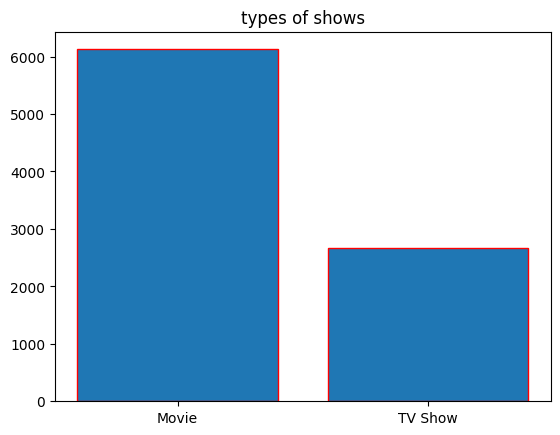

In [37]:
type_no=df['type'].value_counts()
print(type_no)
plt.title('types of shows')
plt.bar(type_no.index, type_no.values, edgecolor='red')
plt.show()

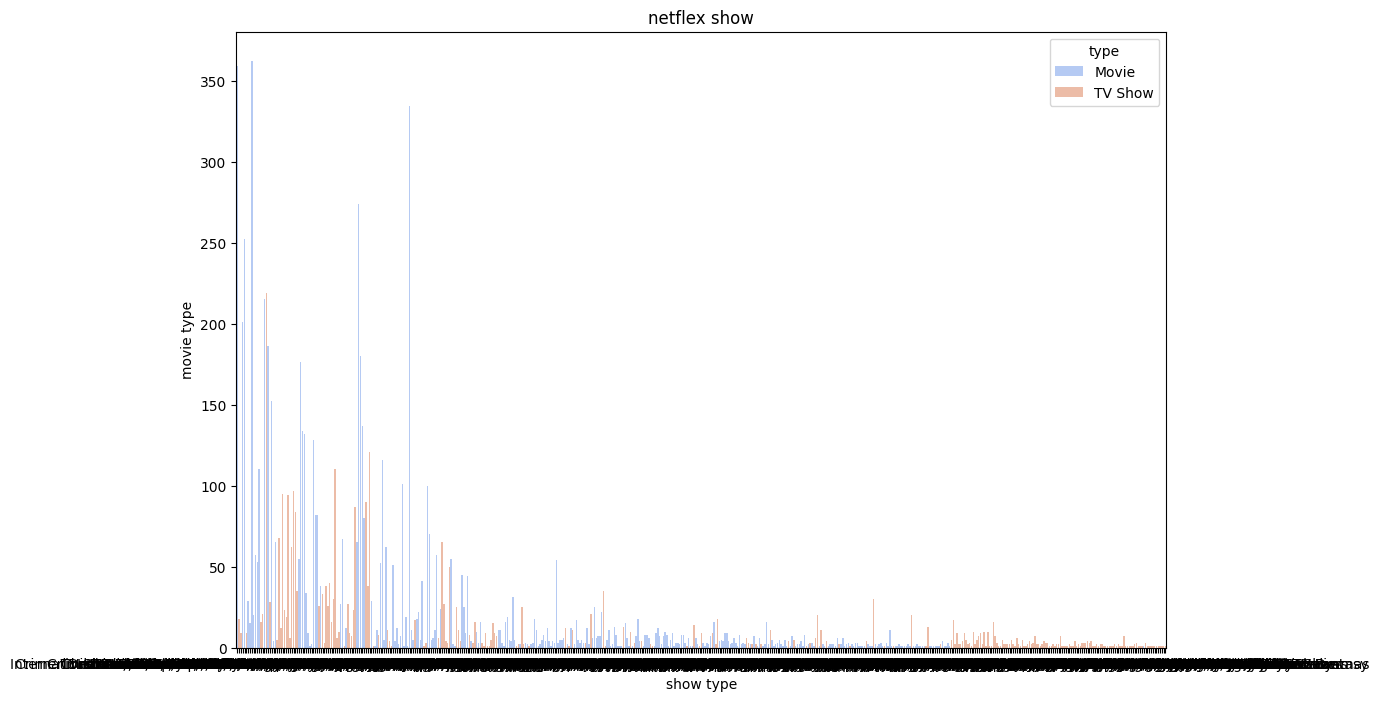

In [43]:
plt.figure(figsize=(12,8))
sns.countplot(x='listed_in',hue='type',data=df,palette='coolwarm')
plt.title('netflex show')
plt.xlabel('show type')
plt.ylabel('movie type')
plt.show()

In [66]:
movie_release_year_counts = df[df['type'] == 'Movie']['release_year'].value_counts().sort_index()
tv_show_release_year_counts = df[df['type'] == 'TV Show']['release_year'].value_counts().sort_index()

movie_country_counts = df[df['type'] == 'Movie']['country'].value_counts().head(10) # Top 10 countries
tv_show_country_counts = df[df['type'] == 'TV Show']['country'].value_counts().head(10) # Top 10 countries

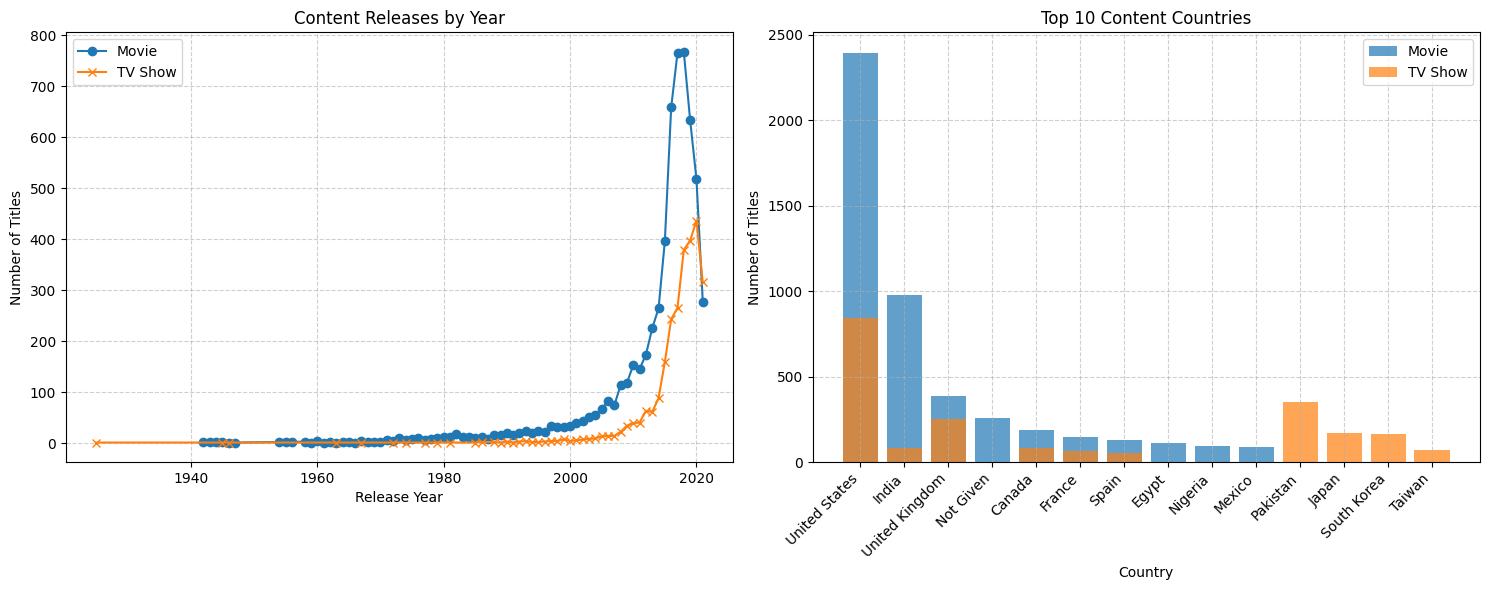

In [67]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for release year
plt.plot(movie_release_year_counts.index, movie_release_year_counts.values, label='Movie', marker='o')
plt.plot(tv_show_release_year_counts.index, tv_show_release_year_counts.values, label='TV Show', marker='x')
plt.title('Content Releases by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2) # Second subplot for country distribution
plt.bar(movie_country_counts.index, movie_country_counts.values, label='Movie', alpha=0.7)
plt.bar(tv_show_country_counts.index, tv_show_country_counts.values, label='TV Show', alpha=0.7)
plt.title('Top 10 Content Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()